# Exploring the telemetry dataset

A first look at the processed data: one qualifying session, two teammates in the same car, and a lap deleted for track limits. Everything here reads the Parquet files through DuckDB views (`race_engineer.data.store.connect`).

The session is set in the next cell; any processed session works.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

from race_engineer.config import REPORT_DIR, WINDOW_BEFORE_M
from race_engineer.data.store import connect

con = connect()
FIG = REPORT_DIR / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 9})

YEAR, ROUND, SESSION = 2026, 1, 'Q'
W = f"year = {YEAR} and round = {ROUND} and session = '{SESSION}'"
info = con.sql(f'select event, grid_step_m, track_length_m from sessions where {W}').df().iloc[0]
STEP = float(info.grid_step_m)
print(f'{info.event} {YEAR} {SESSION}: track {info.track_length_m:,.0f} m, grid step {STEP:g} m')

Australian Grand Prix 2026 Q: track 5,254 m, grid step 5 m


## What's in the dataset

In [2]:
con.sql('''select year, session, count(*) sessions, sum(n_laps) laps,
                  sum(n_grid_ok) lap_grids, sum(n_segments) segments,
                  sum(n_track_limit_events) track_limit_labels
           from sessions group by all order by year, session''').df()

,year,session,sessions,laps,lap_grids,segments,track_limit_labels
0,2022,Q,22,6985.0,4484.0,73129.0,89.0
1,2022,R,22,23577.0,22507.0,367168.0,259.0
2,2022,S,3,1305.0,1243.0,17927.0,34.0
3,2023,Q,22,7419.0,4716.0,75804.0,182.0
4,2023,R,22,24420.0,23278.0,380234.0,412.0
5,2023,S,6,2176.0,1939.0,30415.0,48.0
6,2023,SS,6,1476.0,962.0,14717.0,44.0
7,2024,Q,24,7590.0,4502.0,73778.0,165.0
8,2024,R,24,26604.0,25866.0,424442.0,346.0
9,2024,S,6,2418.0,2271.0,35433.0,45.0


## The fastest laps

Each driver's best clean qualifying lap. The two fastest here are teammates, so they had the same car: the differences below come from the drivers.

In [3]:
best = con.sql(f'''
    select driver, team, lap_id, lap_number, lap_time_s from laps
    where {W} and lap_class = 'push' and grid_ok
    qualify row_number() over (partition by driver order by lap_time_s) = 1
    order by lap_time_s''').df()
A = best.iloc[0]
B = best[(best.team == A.team) & (best.driver != A.driver)].iloc[0]  # A's teammate
best.head(8)

,driver,team,lap_id,lap_number,lap_time_s
0,RUS,Mercedes,2026_01_Q_63_21,21,78.518
1,ANT,Mercedes,2026_01_Q_12_17,17,78.811
2,HAD,Red Bull Racing,2026_01_Q_6_18,18,79.303
3,LEC,Ferrari,2026_01_Q_16_23,23,79.327
4,PIA,McLaren,2026_01_Q_81_25,25,79.380
5,NOR,McLaren,2026_01_Q_1_25,25,79.475
6,HAM,Ferrari,2026_01_Q_44_24,24,79.478
7,LIN,Racing Bulls,2026_01_Q_41_14,14,79.971


In [4]:
CHANNELS = ['time_s', 'speed', 'throttle', 'brake', 'gear', 'x_m', 'y_m', 'offset_m']

def lap_grid(lap_id):
    row = con.sql(f"select * from lap_grids where lap_id = '{lap_id}'").df().iloc[0]
    return {c: np.asarray(row[c]) for c in CHANNELS}

ga, gb = lap_grid(A.lap_id), lap_grid(B.lap_id)
dist = np.arange(len(ga['speed'])) * STEP
corners = con.sql(f'select number, letter, apex_m, x_m, y_m from corners where {W} order by apex_m').df()
print(f'{A.driver} {A.lap_time_s:.3f}s vs {B.driver} {B.lap_time_s:.3f}s '
      f'(gap {B.lap_time_s - A.lap_time_s:.3f}s); {len(corners)} turns')

RUS 78.518s vs ANT 78.811s (gap 0.293s); 14 turns


## Track map

The fastest lap's position trace, coloured by speed, with the official turn numbers.

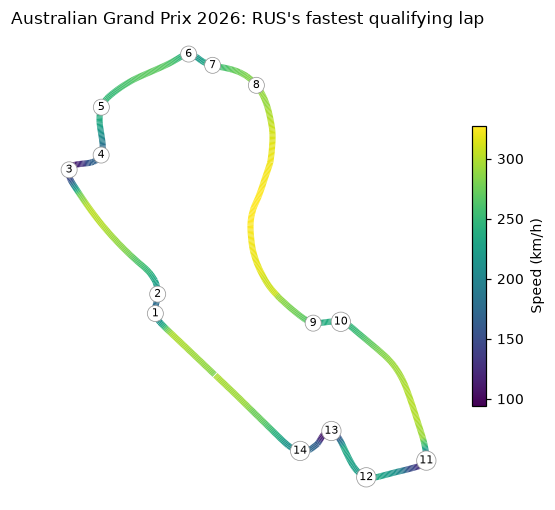

In [5]:
pts = np.column_stack([ga['x_m'], ga['y_m']])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
lc = LineCollection(np.stack([pts[:-1], pts[1:]], axis=1), cmap='viridis', linewidth=4)
lc.set_array(ga['speed'][:-1])
ax.add_collection(lc)
ax.autoscale(); ax.set_aspect('equal'); ax.axis('off')
for c in corners.itertuples():
    ax.annotate(f'{c.number}{c.letter}', (c.x_m, c.y_m), fontsize=7, ha='center', va='center',
                bbox=dict(boxstyle='circle,pad=0.25', fc='white', ec='0.6', lw=0.5))
fig.colorbar(lc, ax=ax, shrink=0.6, label='Speed (km/h)')
ax.set_title(f"{info.event} {YEAR}: {A.driver}'s fastest qualifying lap")
fig.savefig(FIG / 'track_map_speed.png', bbox_inches='tight')

## Where the time went

Both laps sit on the same 5 m distance grid, so subtracting their `time_s` arrays gives the gap at every point of the lap. When the line climbs, the second driver is losing time.

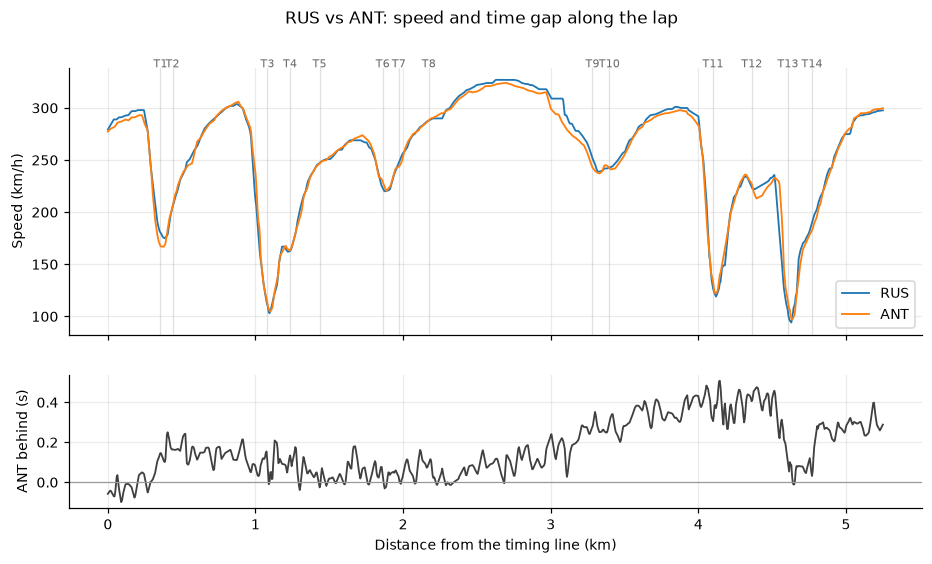

In [6]:
delta = gb['time_s'] - ga['time_s']
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True, height_ratios=[2, 1])
ax1.plot(dist / 1000, ga['speed'], lw=1.2, label=A.driver)
ax1.plot(dist / 1000, gb['speed'], lw=1.2, label=B.driver)
top = ga['speed'].max() + 12
for c in corners.itertuples():
    ax1.axvline(c.apex_m / 1000, color='0.88', lw=0.8, zorder=0)
    ax1.text(c.apex_m / 1000, top, f'T{c.number}', ha='center', fontsize=7, color='0.4')
ax1.set_ylabel('Speed (km/h)'); ax1.legend(loc='lower right')
ax2.plot(dist / 1000, delta, color='0.25', lw=1.2)
ax2.axhline(0, color='0.6', lw=0.8)
ax2.set_ylabel(f'{B.driver} behind (s)'); ax2.set_xlabel('Distance from the timing line (km)')
fig.suptitle(f'{A.driver} vs {B.driver}: speed and time gap along the lap', y=0.98)
fig.savefig(FIG / 'teammates_lap_delta.png', bbox_inches='tight')

## One corner up close

A corner segment runs from 250 m before the apex to 150 m after it: 80 points on the grid. This is the unit the model learns from. The corner below is the one where push laps varied most in this session.

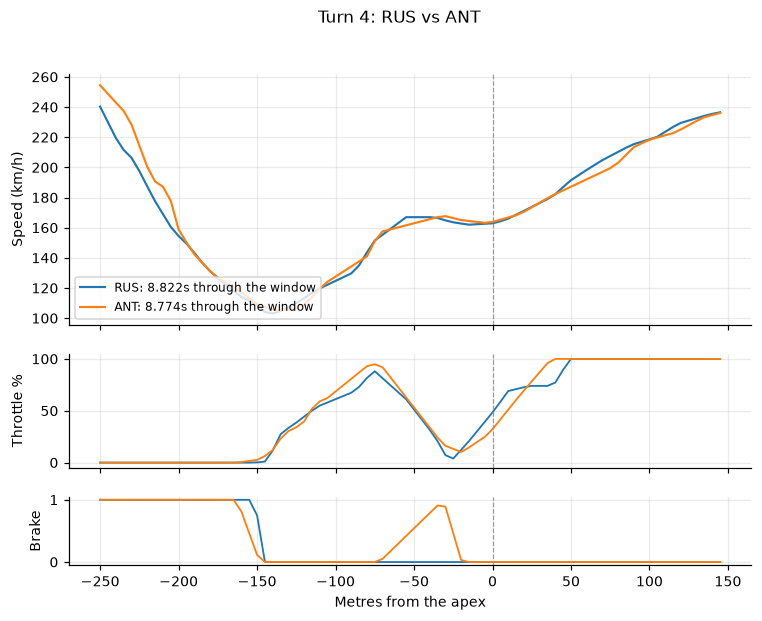

In [7]:
CORNER = int(con.sql(f'''select corner from segments where {W} and lap_class = 'push'
                         group by corner order by stddev(segment_time_s) desc limit 1''').fetchone()[0])
seg = con.sql(f'''select driver, speed, throttle, brake, time_s from segments
                  where lap_id in ('{A.lap_id}', '{B.lap_id}') and corner = {CORNER}''').df()
x = np.arange(80) * STEP - WINDOW_BEFORE_M
fig, axes = plt.subplots(3, 1, figsize=(8, 5.8), sharex=True, height_ratios=[2.2, 1, 0.6])
for r in seg.itertuples():
    axes[0].plot(x, r.speed, lw=1.4, label=f'{r.driver}: {np.asarray(r.time_s)[-1]:.3f}s through the window')
    axes[1].plot(x, r.throttle, lw=1.2)
    axes[2].plot(x, r.brake, lw=1.2)
for ax in axes: ax.axvline(0, color='0.6', lw=0.8, ls='--')
axes[0].set_ylabel('Speed (km/h)'); axes[0].legend(loc='lower left', fontsize=8)
axes[1].set_ylabel('Throttle %'); axes[2].set_ylabel('Brake'); axes[2].set_xlabel('Metres from the apex')
fig.suptitle(f'Turn {CORNER}: {A.driver} vs {B.driver}', y=0.98)
fig.savefig(FIG / 'teammates_corner.png', bbox_inches='tight')

## What a labelled mistake looks like

Race control deletes lap times for exceeding track limits at a named turn, which pins a mistake to one segment. Not every label is a real attempt: in this session Russell's *out-lap* was deleted for track limits at Turn 9, while he was warming his tyres. So labels only count on clean laps (`push` or `race`).

Below, a labelled segment on a clean lap (red) against the same driver's other clean laps through the same corner (grey), preferring this session.

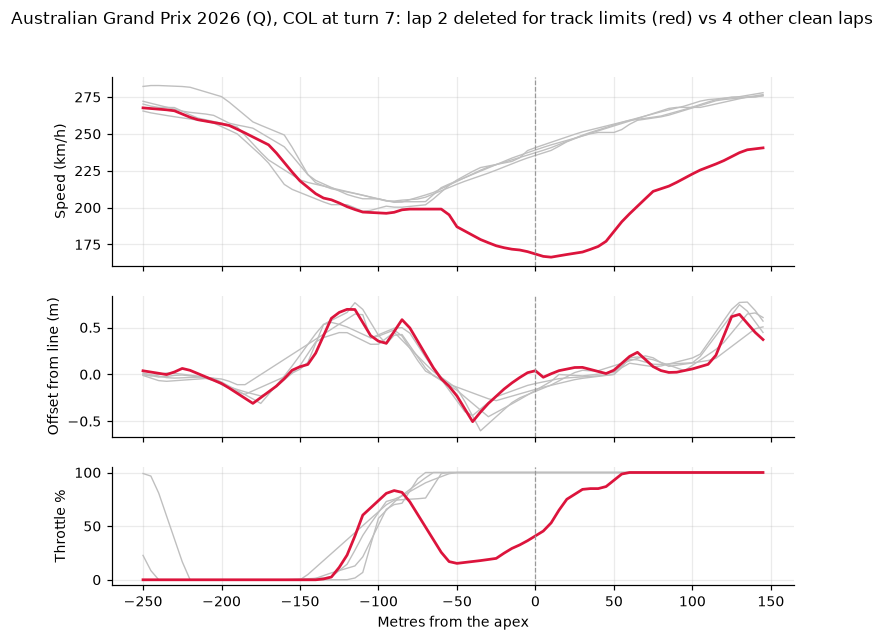

In [8]:
ev = con.sql(f'''
    select e.year, e.round, e.session, e.driver, e.lap_number, e.turn, s2.event from events e
    join laps l on l.year = e.year and l.round = e.round and l.session = e.session
     and l.driver = e.driver and l.lap_number = e.lap_number
    join segments s on s.lap_id = l.lap_id and s.corner = e.turn
    join sessions s2 on s2.year = e.year and s2.round = e.round and s2.session = e.session
    where e.kind = 'track_limits' and e.drivers_same_lap_turn = 1
      and l.lap_class in ('push', 'race')
    order by (e.year = {YEAR} and e.round = {ROUND} and e.session = '{SESSION}') desc,
             e.year desc, e.round, e.driver limit 1''').df().iloc[0]
W2 = f"year = {ev.year} and round = {ev['round']} and session = '{ev.session}'"
same = con.sql(f'''select lap_number, speed, offset_m, throttle from segments
                   where {W2} and driver = '{ev.driver}' and corner = {ev.turn}
                   and (lap_class in ('push', 'race') or lap_number = {ev.lap_number})''').df()
flag = same[same.lap_number == ev.lap_number].iloc[0]
rest = same[same.lap_number != ev.lap_number]
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True, height_ratios=[1.6, 1.2, 1])
for col, ax, label in [('speed', axes[0], 'Speed (km/h)'), ('offset_m', axes[1], 'Offset from line (m)'),
                       ('throttle', axes[2], 'Throttle %')]:
    for r in rest[col]: ax.plot(x, r, color='0.75', lw=0.9)
    ax.plot(x, flag[col], color='crimson', lw=1.8)
    ax.axvline(0, color='0.6', lw=0.8, ls='--'); ax.set_ylabel(label)
axes[2].set_xlabel('Metres from the apex')
fig.suptitle(f'{ev.event} {ev.year} ({ev.session}), {ev.driver} at turn {ev.turn}: lap {ev.lap_number} '
             f'deleted for track limits (red) vs {len(rest)} other clean laps', y=0.98)
fig.savefig(FIG / 'labelled_mistake.png', bbox_inches='tight')

## Takeaways for modelling

- The 5 m grid makes laps directly comparable: gaps, corner times and traces subtract cleanly.
- Differences between teammates are small and local: a few hundredths per corner, from braking point, minimum speed and throttle pickup. That's the signal the style model has to pick up.
- A mistake is a departure from the driver's own normal trace at that corner, especially in lateral offset and throttle, which is what the anomaly detector will score.
- Only laps with deleted times are labelled, so most mistakes are unlabelled: evaluation needs the weak labels *and* a manual review.